In [697]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv

--2025-11-25 20:42:50--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134914826 (129M) [text/plain]
Saving to: ‘all_bills.csv.14’

all_bills.csv.14    100%[===================>] 128.66M  16.5MB/s    in 8.1s    

2025-11-25 20:42:59 (15.9 MB/s) - ‘all_bills.csv.14’ saved [134914826/134914826]



In [698]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv

--2025-11-25 20:42:59--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 516681 (505K) [text/plain]
Saving to: ‘weeks.csv.14’

weeks.csv.14        100%[===================>] 504.57K   651KB/s    in 0.8s    

2025-11-25 20:43:00 (651 KB/s) - ‘weeks.csv.14’ saved [516681/516681]



In [699]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv

--2025-11-25 20:43:00--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10851 (11K) [text/plain]
Saving to: ‘parishes.csv.14’

parishes.csv.14     100%[===================>]  10.60K  --.-KB/s    in 0s      

2025-11-25 20:43:00 (102 MB/s) - ‘parishes.csv.14’ saved [10851/10851]



In [700]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv

--2025-11-25 20:43:00--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8849190 (8.4M) [text/plain]
Saving to: ‘subtotals.csv.14’

subtotals.csv.14    100%[===================>]   8.44M  18.0MB/s    in 0.5s    

2025-11-25 20:43:01 (18.0 MB/s) - ‘subtotals.csv.14’ saved [8849190/8849190]



In [701]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/duplicate_bills_removable.csv

--2025-11-25 20:43:01--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/duplicate_bills_removable.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29509 (29K) [text/plain]
Saving to: ‘duplicate_bills_removable.csv.14’

duplicate_bills_rem 100%[===================>]  28.82K   177KB/s    in 0.2s    

2025-11-25 20:43:02 (177 KB/s) - ‘duplicate_bills_removable.csv.14’ saved [29509/29509]



In [702]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict

# Configure plotting
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000', '#004F71']

In [703]:
# Read in the all_bills.csv and weeks.csv files
all_bills = pd.read_csv(Path('all_bills.csv'))
weeks = pd.read_csv(Path('weeks.csv'))
subtotals = pd.read_csv('subtotals.csv')

# Merge the two dataframes on 'joinid', bringing in only selected columns from weeks
bills = all_bills.merge(
    weeks[['joinid', 'start_day', 'end_day', 'start_month', 'end_month','week_number', 'year_range']],
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
bills['start_day'] = bills['start_day'].astype('Int64')
bills['end_day'] = bills['end_day'].astype('Int64')

# Join the parish IDs
parishes = pd.read_csv(Path('parishes.csv'))
bills = bills.merge(parishes, left_on='parish_id', right_on='id', how='left')

# remove general bills by removing all bills with 'week_number' > 55
bills = bills[bills['week_number'] <= 55]

# remove Westminster pesthouse counts, which are not included in bills' subotals
bills = bills[bills['parish_id'] != 19]

# return head() for bills, sorted by year
bills.sort_values('year').head(10)

#print the total number of "weeks", including annual bills
num_unique_weeks = len(weeks)
print(f"Total number of unique weeks: {num_unique_weeks}")

#print the number of unique joinid in weeks
print(f"Total number of unique joinid in weeks: {weeks['joinid'].nunique()}")

#print the number of unique joinid in bills
print(f"Total number of unique joinid in bills: {bills['joinid'].nunique()}")

#identify joinid in weeks but not in bills
diff = set(weeks['joinid']) - set(bills['joinid'])

#print length of diff
print(f"Number of joinid in bills but not in weeks: {len(diff)}")

# print number of joinid in bills but not in weeks
# print(f"Joinid in bills but not in weeks: {set(weeks['joinid']) - set(bills['joinid'])}")

#read in the list of duplicate bills to remove
duplicate_bills = pd.read_csv(Path('duplicate_bills_removable.csv'))

#print the number of rows in duplicate_bills, should be 174
print(f"Number of rows in duplicate_bills: {len(duplicate_bills)}")

#print the number of unique joinid in duplicate_bills, there should be 10 less as 10 bills were included 3 times
print(f"Number of unique joinid in duplicate_bills: {len(duplicate_bills['joinid'].unique())}")

unique_joinid = duplicate_bills['joinid'].unique()

#export unique_joinid to excel
#pd.DataFrame(unique_joinid, columns=['joinid']).to_csv('unique_joinid.csv', index=False)


Total number of unique weeks: 5555
Total number of unique joinid in weeks: 5505
Total number of unique joinid in bills: 5219
Number of joinid in bills but not in weeks: 286
Number of rows in duplicate_bills: 174
Number of unique joinid in duplicate_bills: 164


In [704]:
# With the duplicate_bills data ready, we need to match data in our bills
# dataframe where a duplicate_bill row = bill row.

# Create a duplication key we can match against in bills data frame
bills['duplication_key'] = (
    bills['unique_identifier'].astype(str) + '-' +
    bills['count_type'].astype(str) + '-' +
    bills['joinid'].astype(str)
)

In [705]:
# Create a duplication key we can match against in duplicate_bills data frame
duplicate_bills['duplication_key'] = (
    duplicate_bills['unique_identifier'].astype(str) + '-' +
    duplicate_bills['count_type'].astype(str) + '-' +
    duplicate_bills['joinid'].astype(str)
)

In [706]:
# Filter out rows from 'bills' that have a unique_identifier present in duplicate_bills
bills_deduped = bills[~bills['duplication_key'].isin(duplicate_bills['duplication_key'])]

# Print the number of unique joinid in bills
print(f"Number of unique joinid in bills: {len(bills['joinid'].unique())}")

# Print the number of unique joinid in bills_deduped
print(f"Number of unique joinid in bills_deduped: {len(bills_deduped['joinid'].unique())}")

# Find the joinid that is not in the intersection of bills and bills_deduped
joinid_difference = set(bills['joinid'].unique()) - set(bills_deduped['joinid'].unique())

#print the first 10 joinid in joinid_difference
print(f"First 10 joinid in joinid_difference: {list(joinid_difference)[:10]}")

bills = bills_deduped

Number of unique joinid in bills: 5219
Number of unique joinid in bills_deduped: 5219
First 10 joinid in joinid_difference: []


In [707]:
# THIS CHECKS IF THERE'S ANYTHING ILLEGIBLE IN THE GENERAL BILLS
# MAY NOT BE USEFUL, MAY ONLY CARE ABOUT LEGIBILITY OF THE SPECIFIC FIELDS FOR SUBTOTALS?

general_bills_only  = bills[bills['bill_type'] == 'general']
general_bills_illegible = general_bills_only[general_bills_only['illegible'] == True]
general_bills_legible = general_bills_only[general_bills_only['illegible'] == False]

print(len(general_bills_illegible))
print(len(general_bills_legible))

0
0


# Rethinking some of this...

Two possible checks here:
1. Weekly subtotals → Annual subtotals - summing across weeks (time)
2. Parish counts → Subtotals - summing across parishes (space)

## 1. Does the sum of individual weekly parish counts equal the annual totals reported in the general bills?

In [708]:
# Filter to weekly bills only (not general bill parish records)
weekly_bills = bills[bills['bill_type'] == 'weekly']

# Filter to weekly bills after 1663, when annual series are close to complete
weekly_bills = weekly_bills[weekly_bills['year'] >= 1663]

# Sum all parish counts by year and count_type
weekly_parish_sums = weekly_bills.groupby(['year_range', 'count_type'])['count'].sum().reset_index()
weekly_parish_sums.rename(columns={'count': 'weekly_parish_sum'}, inplace=True)

print(f"Weekly parish sums: {len(weekly_parish_sums)} year×count_type combinations")
display(weekly_parish_sums.head(100))

Weekly parish sums: 130 year×count_type combinations


,year_range,count_type,weekly_parish_sum
0,1662-1663,buried,10780
1,1662-1663,plague,13
2,1663-1664,buried,17829
3,1663-1664,plague,6
4,1664-1665,buried,75681
...,...,...,...
95,1718-1719,buried,19115
96,1719-1720,buried,24856
97,1720-1721,buried,23866
98,1721-1722,buried,25278


In [709]:
# Get general bill subtotals and sum across all geographic areas
general_subs = subtotals[subtotals['bill_type'] == 'general']

# Filter to after 1663 when annual series are close to complete
general_subs = general_subs[general_subs['year'] >= 1663]

# Dump any general bill 'source' that contains "Laxton" -- fix duplication issue
general_subs = general_subs[~general_subs['source'].str.contains('Laxton')]

# Add a field named 'year_range' and populate with (year-1)-year
general_subs['year_range'] = general_subs['year'].astype(str)
general_subs['year_range'] = general_subs['year_range'].apply(lambda x: str(int(x) - 1) + '-' + x)

# Drop christenings
general_subs = general_subs[general_subs['count_type'] != 'christened']

general_subs.sort_values('year_range').head(100)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,year_range
11011,Within the walls,buried,3002,1663,1662121716631215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1662-1663-GeneralBill,1662-1663
11012,Within the walls,plague,1,1663,1662121716631215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1662-1663-GeneralBill,1662-1663
11014,Without the walls,buried,5608,1663,1662121716631215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1662-1663-GeneralBill,1662-1663
11015,Without the walls,plague,6,1663,1662121716631215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1662-1663-GeneralBill,1662-1663
11017,Middlesex and Surrey,buried,4269,1663,1662121716631215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1662-1663-GeneralBill,1662-1663
...,...,...,...,...,...,...,...,...,...,...,...
11143,Within the walls,buried,2801,1674,1673121616741215,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1673-1674-GeneralBill,1673-1674
11164,Westminster,buried,3026,1675,1674121516751214,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1674-1675-GeneralBill,1674-1675
11162,Middlesex and Surrey,plague,1,1675,1674121516751214,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1674-1675-GeneralBill,1674-1675
11161,Middlesex and Surrey,buried,5677,1675,1674121516751214,general,False,False,2023-05-29-millar-generalbills-preplague-paris...,Millar-1674-1675-GeneralBill,1674-1675


In [710]:
# Sum all 4 geographic areas to get total for London
general_annual = general_subs.groupby(['year', 'year_range', 'count_type'])['count'].sum().reset_index()
general_annual.rename(columns={'count': 'general_total'}, inplace=True)

# Keep a version of the full dataset for the 'illegible' graphic
general_annual_full = general_annual

# Filter to after 1663 when annual series are close to complete
general_annual = general_annual[general_annual['year'] >= 1663]

print(f"General annual totals: {len(general_annual)} year×count_type combinations")
display(general_annual.head(100))

General annual totals: 178 year×count_type combinations


,year,year_range,count_type,general_total
0,1663,1662-1663,buried,15356
1,1663,1662-1663,plague,9
2,1664,1663-1664,buried,18297
3,1664,1663-1664,plague,6
4,1665,1664-1665,buried,97306
...,...,...,...,...
95,1710,1709-1710,plague,0
96,1711,1710-1711,buried,19833
97,1711,1710-1711,plague,0
98,1712,1711-1712,buried,21198


In [711]:
# Compare them
comparison = pd.merge(
  weekly_parish_sums,
  general_annual,
  on=['year_range', 'count_type'],
  how='outer'
)

comparison_full = pd.merge(
    weekly_parish_sums,
    general_annual_full,
    on=['year_range', 'count_type'],
    how='outer'
)

# Filter to only where general_total is not empty
comparison = comparison[comparison['general_total'].notna()]

# Calculate differences
comparison['difference'] = comparison['weekly_parish_sum'] - comparison['general_total']
comparison['pct_diff'] = (comparison['difference'] / comparison['general_total'] * 100).round(2)

print("Comparison of weekly parish sums vs general bill totals:")
display(comparison.sort_values(['year_range', 'count_type']).head(10))

Comparison of weekly parish sums vs general bill totals:


,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff
0,1662-1663,buried,10780.0,1663.0,15356.0,-4576.0,-29.80
1,1662-1663,plague,13.0,1663.0,9.0,4.0,44.44
2,1663-1664,buried,17829.0,1664.0,18297.0,-468.0,-2.56
3,1663-1664,plague,6.0,1664.0,6.0,0.0,0.00
4,1664-1665,buried,75681.0,1665.0,97306.0,-21625.0,-22.22
5,1664-1665,plague,50845.0,1665.0,68598.0,-17753.0,-25.88
6,1665-1666,buried,13502.0,1666.0,12738.0,764.0,6.00
7,1665-1666,plague,4374.0,1666.0,1998.0,2376.0,118.92
8,1666-1667,buried,15780.0,1667.0,15842.0,-62.0,-0.39
9,1666-1667,plague,121.0,1667.0,35.0,86.0,245.71


## 2. Are the weekly totals correctly summed to produce the annual subtotals?

If each weekly bill has preprinted subtotals (within/without/etc.), and the general bills report a within/without/etc., are these the same?

In [712]:
# Before merging, drop any existing 'year_range' from subtotals created in a previous cell.
if 'year_range' in subtotals.columns:
    subtotals = subtotals.drop(columns=['year_range'])

# Merge the subtotals and weeks dataframes on 'joinid', bringing in only selected columns from weeks
subtotals = subtotals.merge(
    weeks[['joinid', 'year_range']],
    on='joinid',
    how='left'
)

weekly = subtotals[subtotals['bill_type'] == 'weekly'].copy()
general = subtotals[subtotals['bill_type'] == 'general'].copy()

#filter weekly and general to years after 1663 when data series is more complete
weekly = weekly[weekly['year'] >= 1663]
general = general[general['year'] >= 1663]

# print head of weekly
weekly.head(20)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,year_range
168,Within the walls,christened,0,1663,1663121516631222,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
169,Within the walls,buried,63,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
170,Within the walls,plague,0,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
171,Without the walls,christened,0,1663,1663121516631222,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
172,Without the walls,buried,123,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
173,Without the walls,plague,0,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
174,Middlesex and Surrey,christened,0,1663,1663121516631222,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
175,Middlesex and Surrey,buried,80,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
176,Middlesex and Surrey,plague,0,1663,1663121516631222,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664
177,Westminster,christened,0,1663,1663121516631222,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-01-recto,1663-1664


In [713]:
# Sum weekly subtotals by year/category/count_type
weekly_sums = weekly.groupby(
    ['subtotal_category', 'count_type', 'year_range']
)['count'].sum().reset_index()
weekly_sums.rename(columns={'count': 'weekly_sum'}, inplace=True)

display(weekly_sums.head(20))

,subtotal_category,count_type,year_range,weekly_sum
0,Middlesex and Surrey,buried,1662-1663,4177
1,Middlesex and Surrey,buried,1663-1664,4723
2,Middlesex and Surrey,buried,1664-1665,22156
3,Middlesex and Surrey,buried,1665-1666,8820
4,Middlesex and Surrey,buried,1666-1667,5685
5,Middlesex and Surrey,buried,1667-1668,5841
6,Middlesex and Surrey,buried,1668-1669,11789
7,Middlesex and Surrey,buried,1669-1670,8362
8,Middlesex and Surrey,buried,1670-1671,5650
9,Middlesex and Surrey,buried,1671-1672,6007


In [714]:
weekly_sums_1695_check = weekly_sums[weekly_sums['year_range'] == '1695-1696']
display(weekly_sums_1695_check)

,subtotal_category,count_type,year_range,weekly_sum
33,Middlesex and Surrey,buried,1695-1696,6333
124,Middlesex and Surrey,christened,1695-1696,4825
215,Middlesex and Surrey,plague,1695-1696,0
306,Westminster,buried,1695-1696,4148
397,Westminster,christened,1695-1696,3098
488,Westminster,plague,1695-1696,0
579,Within the walls,buried,1695-1696,2577
670,Within the walls,christened,1695-1696,2055
761,Within the walls,plague,1695-1696,0
852,Without the walls,buried,1695-1696,5941


In [715]:
# Get general bill subtotals
general_totals = general.groupby(
  ['subtotal_category', 'count_type', 'year_range']
)['count'].sum().reset_index()

general_totals.rename(columns={'count': 'general_total'}, inplace=True)

In [716]:
# Compare weekly sums to general totals
comparison_subtotals_general = pd.merge(
    weekly_sums,
    general_totals,
    on=['subtotal_category', 'count_type', 'year_range'],
    how='inner'  # Only years with both
)

comparison_subtotals_general['difference'] = comparison_subtotals_general['general_total'] - comparison_subtotals_general['weekly_sum']
comparison_subtotals_general['pct_diff'] = (comparison_subtotals_general['difference'] / comparison_subtotals_general['general_total'] * 100).round(2)

# Remove the christened data
comparison_subtotals_general = comparison_subtotals_general[comparison_subtotals_general['count_type'] != 'christened']

print(f"Comparisons: {len(comparison_subtotals_general)}")
display(comparison_subtotals_general.sort_values('year_range').head(20))

Comparisons: 704


,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
0,Middlesex and Surrey,buried,1662-1663,4177,4269,92,2.16
440,Westminster,plague,1662-1663,0,0,0,NaN
176,Middlesex and Surrey,plague,1662-1663,2,2,0,0.00
528,Within the walls,buried,1662-1663,2732,3002,270,8.99
704,Within the walls,plague,1662-1663,0,1,1,100.00
792,Without the walls,buried,1662-1663,5558,5608,50,0.89
968,Without the walls,plague,1662-1663,11,6,-5,-83.33
264,Westminster,buried,1662-1663,2365,2477,112,4.52
793,Without the walls,buried,1663-1664,6952,7168,216,3.01
1,Middlesex and Surrey,buried,1663-1664,4723,4885,162,3.32


**NB:** A negative percentage difference between the general bill's printed subtotal and the sum of weekly reports by parish would mean that the weekly bills "undercounted" or the general bill "overcounted."

In [717]:
# SPOT CHECK: Filter for 'buried' counts to examine major discrepancies
buried_discrepancies = comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'buried'].copy()

# Sort by the absolute percentage difference in descending order
major_discrepancies_pct = buried_discrepancies.sort_values(by='pct_diff', ascending=False, key=abs)

print("Top 10 years with the largest percentage discrepancies for 'Buried' counts:")
display(major_discrepancies_pct.head(10))

# Also look at the largest absolute differences
major_discrepancies_abs = buried_discrepancies.sort_values(by='difference', ascending=False, key=abs)
print("\nTop 10 years with the largest absolute discrepancies for 'Buried' counts:")
display(major_discrepancies_abs.head(10))


Top 10 years with the largest percentage discrepancies for 'Buried' counts:


,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
531,Within the walls,buried,1665-1666,4383,1977,-2406,-121.70
795,Without the walls,buried,1665-1666,9141,4543,-4598,-101.21
3,Middlesex and Surrey,buried,1665-1666,8820,4465,-4355,-97.54
267,Westminster,buried,1665-1666,3453,1753,-1700,-96.98
54,Middlesex and Surrey,buried,1717-1718,3549,37940,34391,90.65
846,Without the walls,buried,1717-1718,3340,33748,30408,90.10
582,Within the walls,buried,1717-1718,1133,11036,9903,89.73
318,Westminster,buried,1717-1718,2405,23368,20963,89.71
77,Middlesex and Surrey,buried,1740-1741,7577,56040,48463,86.48
869,Without the walls,buried,1740-1741,4687,34004,29317,86.22



Top 10 years with the largest absolute discrepancies for 'Buried' counts:


,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
77,Middlesex and Surrey,buried,1740-1741,7577,56040,48463,86.48
76,Middlesex and Surrey,buried,1739-1740,13034,53000,39966,75.41
73,Middlesex and Surrey,buried,1736-1737,11695,49496,37801,76.37
78,Middlesex and Surrey,buried,1741-1742,11297,46896,35599,75.91
83,Middlesex and Surrey,buried,1746-1747,11215,46704,35489,75.99
72,Middlesex and Surrey,buried,1735-1736,11848,47296,35448,74.95
85,Middlesex and Surrey,buried,1748-1749,11669,46960,35291,75.15
55,Middlesex and Surrey,buried,1718-1719,7197,42004,34807,82.87
69,Middlesex and Surrey,buried,1732-1733,11200,45696,34496,75.49
54,Middlesex and Surrey,buried,1717-1718,3549,37940,34391,90.65


# Data Viz

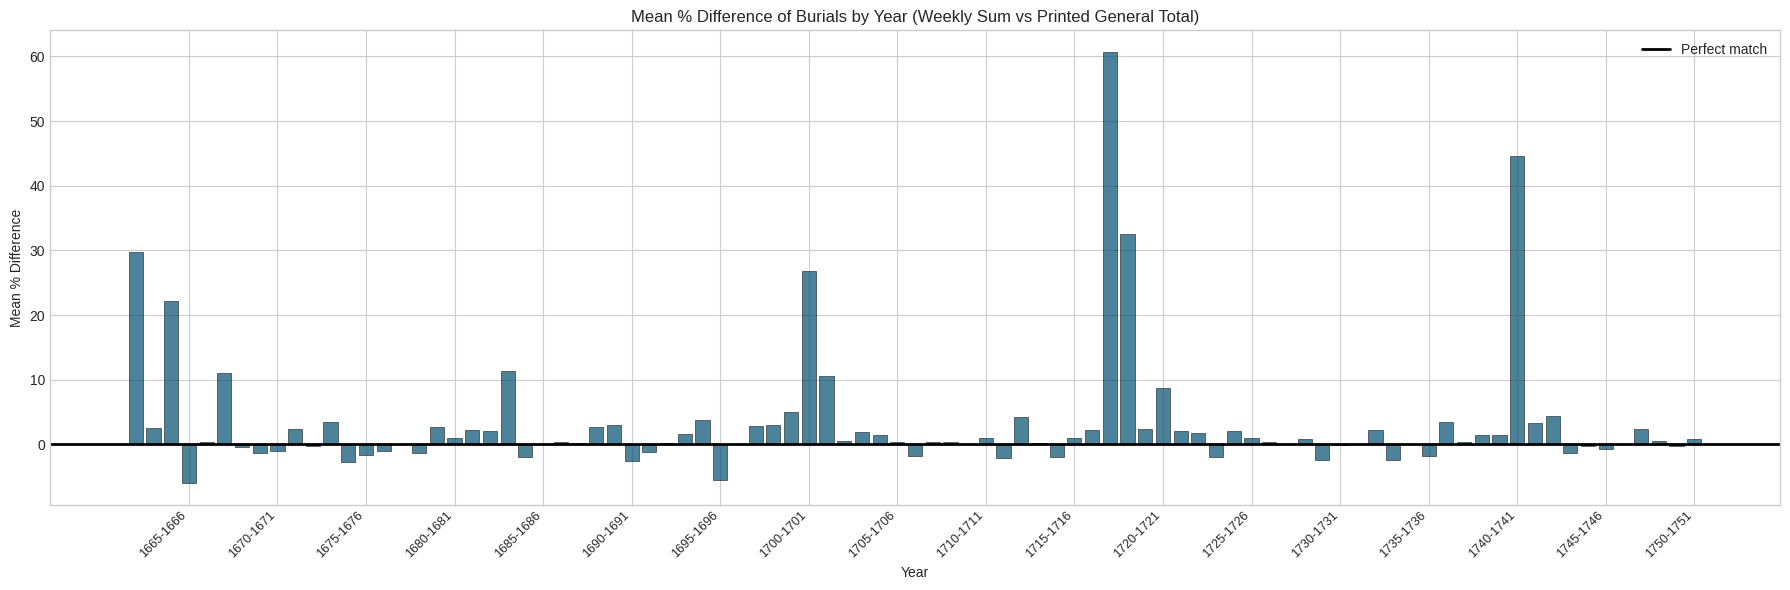

In [718]:
# Per-year trend
fig, ax = plt.subplots(figsize=(18, 6))

# Plot burials only
subset_burials = comparison[comparison['count_type'] == 'buried']

year_avg = subset_burials.groupby('year_range')['pct_diff'].mean()

# Create numeric x-positions for bars
x_pos = range(len(year_avg))

ax.bar(x_pos, -year_avg.values, color=PALETTE[5], alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color="black", linestyle='-', linewidth=2, label='Perfect match')
ax.set_xlabel('Year')
ax.set_ylabel('Mean % Difference')
ax.set_title('Mean % Difference of Burials by Year (Weekly Sum vs Printed General Total)')
ax.legend()

# Show every fifth year
year_labels = year_avg.index.tolist()
year_ticks = []
labels = []
for i, year_range_str in enumerate(year_labels):
    start_year = int(year_range_str.split('-')[0])
    if start_year % 5 == 0:
        year_ticks.append(i)
        labels.append(year_range_str)

# Try using plt.xticks instead of ax.set_xticks
plt.xticks(ticks=year_ticks, labels=labels, rotation=45, ha='right')

# Force matplotlib to not auto-hide labels
ax.tick_params(axis='x', which='major', labelsize=9)
ax.xaxis.set_tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

In [719]:
# Check the data for '1665-1666' in merged_illegible_comparison
#display(merged_illegible_comparison[merged_illegible_comparison['year_range'] == '1665-1666'])

## Comparing buried counts to illegible weeks

In [720]:
# Calculate the percentage of illegible bills per year_range
# Filter bills to only include weekly entries after 1663 for consistency with previous comparisons
weekly_bills_filtered = bills[(bills['bill_type'] == 'weekly') & (bills['year'] >= 1663)].copy()

# Create a separate data frame that can hold data with illegible data removed.
# print the number of unique weeks in bills_legible
print(f"Total number of unique weeks in bills: {len(weekly_bills_filtered['joinid'].unique())}")

# Identify the unique weekly bills with illegible data in the bills data frame
bills_illegible_comparison = weekly_bills_filtered[weekly_bills_filtered['illegible'] == True]

illegible_bills_weeks = bills_illegible_comparison['joinid'].unique()

print(f"Total number of illegible weeks: {len(illegible_bills_weeks)}")

Total number of unique weeks in bills: 4540
Total number of illegible weeks: 907


In [721]:
# Filter out all rows with a joinid from illegible_bills_weeks
legible_bills_weeks = bills[~bills['joinid'].isin(illegible_bills_weeks)]
# Count the illegible weeks for a given year range
illegible_counts = bills_illegible_comparison.groupby('year_range')['joinid'].nunique().reset_index()
# rename columns year_range and illegible_weeks
illegible_counts.rename(columns={'joinid': 'illegible_weeks'}, inplace=True)

illegible_counts.head()

,year_range,illegible_weeks
0,1662-1663,10
1,1663-1664,12
2,1664-1665,10
3,1665-1666,9
4,1668-1669,7


In [722]:
unique_weeks_per_year_range = legible_bills_weeks[legible_bills_weeks['year'] >= 1663]

In [723]:
# Calculate the total number of unique weeks for a given year range (including both legible and illegible)
total_weeks_per_year_range = weekly_bills_filtered.groupby('year_range')['joinid'].nunique().reset_index()
total_weeks_per_year_range.rename(columns={'joinid': 'total_unique_weeks'}, inplace=True)

print("Total number of unique weeks per year range:")
display(total_weeks_per_year_range)

Total number of unique weeks per year range:


,year_range,total_unique_weeks
0,1662-1663,37
1,1663-1664,53
2,1664-1665,47
3,1665-1666,51
4,1666-1667,52
...,...,...
86,1748-1749,52
87,1749-1750,52
88,1750-1751,52
89,1751-1752,27


In [724]:
# Merge illegible_counts with total_weeks_per_year_range to do comparisons
merged_illegible_comparison = illegible_counts.merge(total_weeks_per_year_range, on='year_range', how='left')
# Calculate percentage difference of weeks
merged_illegible_comparison['pct_weeks_illegible'] = (merged_illegible_comparison['illegible_weeks'] / merged_illegible_comparison['total_unique_weeks'] * 100).round(2)

# Merge subset_burials and merged_illegible_comparison
merged_illegible_comparison = subset_burials.merge(merged_illegible_comparison, on='year_range', how='left')

# sort merged_illegible_comparison by general_total
merged_illegible_comparison = merged_illegible_comparison.sort_values('pct_diff', ascending=False)

merged_illegible_comparison.head(100)

,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff,illegible_weeks,total_unique_weeks,pct_weeks_illegible
3,1665-1666,buried,13502.0,1666.0,12738.0,764.0,6.00,9.0,51.0,17.65
33,1695-1696,buried,19008.0,1696.0,18008.0,1000.0,5.55,9.0,53.0,16.98
12,1674-1675,buried,17720.0,1675.0,17244.0,476.0,2.76,7.0,53.0,13.21
28,1690-1691,buried,23260.0,1691.0,22691.0,569.0,2.51,7.0,53.0,13.21
71,1733-1734,buried,26703.0,1734.0,26062.0,641.0,2.46,6.0,53.0,11.32
...,...,...,...,...,...,...,...,...,...,...
38,1700-1701,buried,14996.0,1701.0,20471.0,-5475.0,-26.75,9.0,39.0,23.08
0,1662-1663,buried,10780.0,1663.0,15356.0,-4576.0,-29.80,10.0,37.0,27.03
56,1718-1719,buried,19115.0,1719.0,28347.0,-9232.0,-32.57,6.0,35.0,17.14
78,1740-1741,buried,17834.0,1741.0,32169.0,-14335.0,-44.56,21.0,32.0,65.62


In [725]:
# print the average number of illegible_weeks in merged_illegible_comparison
print(f"Average number of illegible weeks: {merged_illegible_comparison['pct_diff'].mean()}")
print(f"Average number of illegible weeks: {merged_illegible_comparison['pct_diff'].median()}")
print(f"Standard deviation of illegible weeks: {merged_illegible_comparison['pct_diff'].std()}")

Average number of illegible weeks: -3.351685393258427
Average number of illegible weeks: -0.58
Standard deviation of illegible weeks: 9.897804765331811


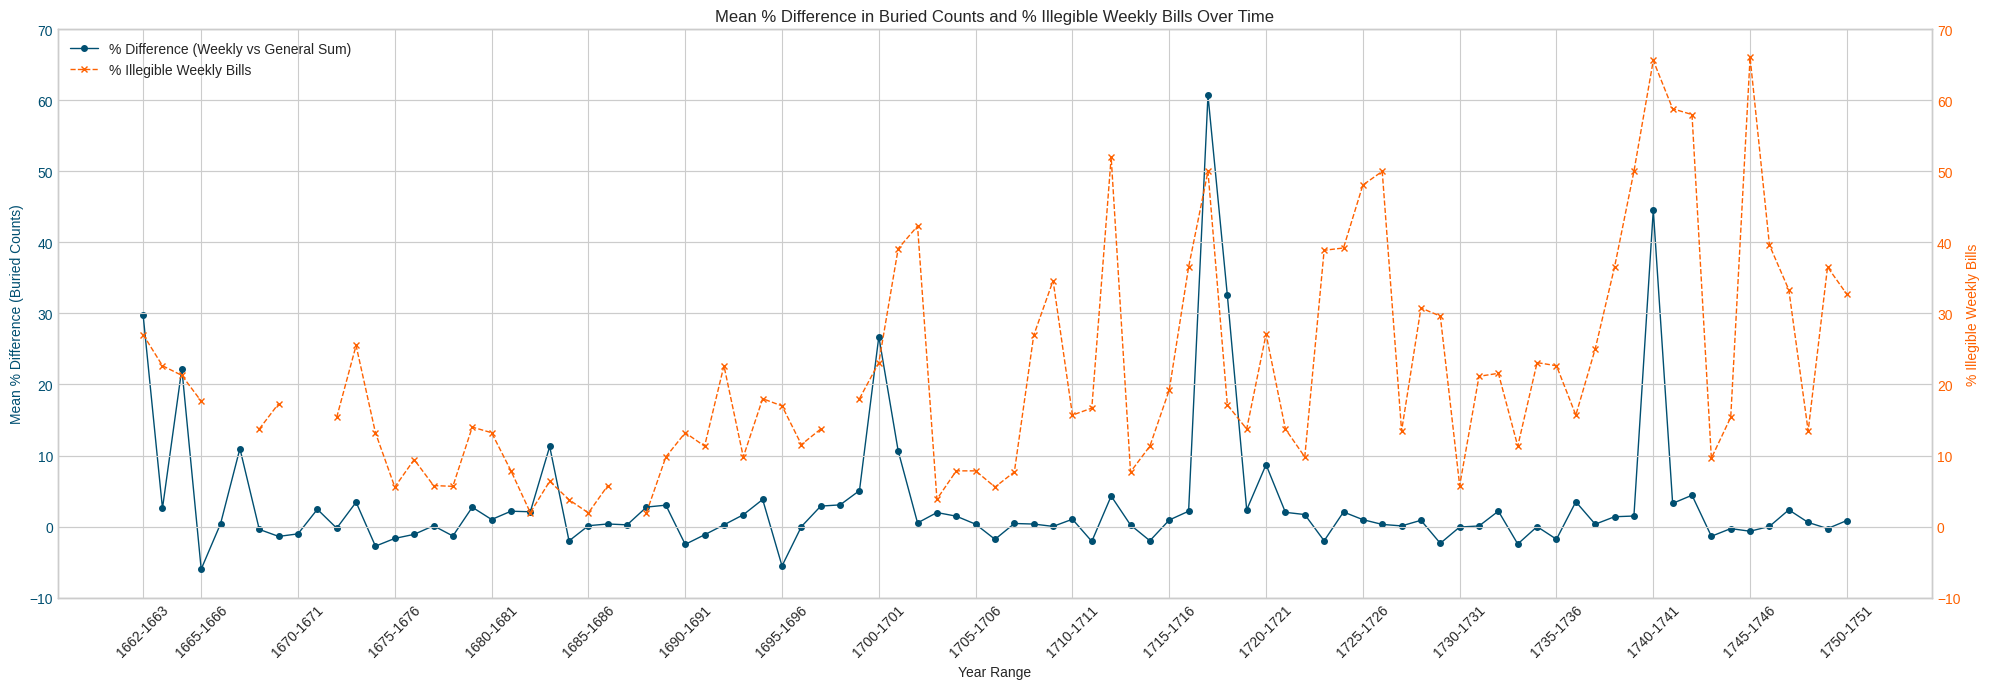

In [726]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(20, 7)) # Increased width

# Sort merged_illegible_comparison by year to ensure chronological order on the x-axis
merged_illegible_comparison = merged_illegible_comparison.sort_values('year', ascending=True)

# Plot percentage difference on ax1
ax1.plot(merged_illegible_comparison['year_range'], -merged_illegible_comparison['pct_diff'], color=PALETTE[5], label='% Difference (Weekly vs General Sum)', marker='o', markersize=4, linewidth=1)
ax1.set_xlabel('Year Range')
ax1.set_ylabel('Mean % Difference (Buried Counts)', color=PALETTE[5])
ax1.tick_params(axis='y', labelcolor=PALETTE[5])
ax1.set_title('Mean % Difference in Buried Counts and % Illegible Weekly Bills Over Time')

# Create a second y-axis for percentage illegible
ax2 = ax1.twinx()
ax2.plot(merged_illegible_comparison['year_range'], merged_illegible_comparison['pct_weeks_illegible'], color=PALETTE[3], label='% Illegible Weekly Bills', linestyle='--', marker='x', markersize=4, linewidth=1)
ax2.set_ylabel('% Illegible Weekly Bills', color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

# Show every fifth year on x-axis, ensuring the first year is always shown
year_labels = merged_illegible_comparison['year_range'].tolist()
year_ticks = []
labels = []

# Always add the first year_range as a tick
if len(year_labels) > 0:
    year_ticks.append(0)
    labels.append(year_labels[0])

# Add subsequent ticks for years divisible by 5, avoiding duplicates
for i, year_range_str in enumerate(year_labels[1:], start=1): # Start from the second element
    start_year = int(year_range_str.split('-')[0])
    if start_year % 5 == 0:
        year_ticks.append(i)
        labels.append(year_range_str)

ax1.set_xticks(year_ticks)
ax1.set_xticklabels(labels, rotation=45, ha='center')

# Force both plots to share the same axis size
ax1.set_ylim(-10, 70)
ax2.set_ylim(-10, 70)

plt.tight_layout()
plt.show()

fig.savefig('buried_illegible_comparison.png', dpi=300, bbox_inches='tight')

### Chart by decade

In [727]:
comparison['decade'] = (comparison['year'] // 10) * 10

print("Added 'decade' column to the comparison DataFrame.")
print(comparison[['year', 'decade']].head(10))

print("\n")

print("Decades in the comparison DataFrame:")
print(comparison['decade'].unique())

Added 'decade' column to the comparison DataFrame.
     year  decade
0  1663.0  1660.0
1  1663.0  1660.0
2  1664.0  1660.0
3  1664.0  1660.0
4  1665.0  1660.0
5  1665.0  1660.0
6  1666.0  1660.0
7  1666.0  1660.0
8  1667.0  1660.0
9  1667.0  1660.0


Decades in the comparison DataFrame:
[1660. 1670. 1680. 1690. 1700. 1710. 1720. 1730. 1740. 1750.]


In [728]:
# Add a 'matches' column for comparison for weekly_sum	and general_total returning
# TRUE or FALSE
for index, row in comparison.iterrows():
    if row['difference'] == 0:
      # the match is True
      comparison.at[index, 'matches'] = True
    else:
      comparison.at[index, 'matches'] = False

grouped_comparison = comparison.groupby(['decade', 'count_type']).agg(
    total_entries=('matches', 'size'),
    mismatched_entries=('matches', lambda x: x.eq(False).sum())
).reset_index()

grouped_comparison['error_rate'] = (grouped_comparison['mismatched_entries'] / grouped_comparison['total_entries']) * 100

grouped_comparison_buried = grouped_comparison[grouped_comparison['count_type'] == 'buried']
grouped_comparison_plague = grouped_comparison[grouped_comparison['count_type'] == 'plague']

In [729]:
display(grouped_comparison_plague)

,decade,count_type,total_entries,mismatched_entries,error_rate
1,1660.0,plague,7,6,85.714286
3,1670.0,plague,10,4,40.000000
5,1680.0,plague,10,0,0.000000
7,1690.0,plague,10,0,0.000000
9,1700.0,plague,10,8,80.000000
11,1710.0,plague,10,10,100.000000
13,1720.0,plague,10,10,100.000000
15,1730.0,plague,10,10,100.000000
17,1740.0,plague,10,10,100.000000
19,1750.0,plague,2,2,100.000000


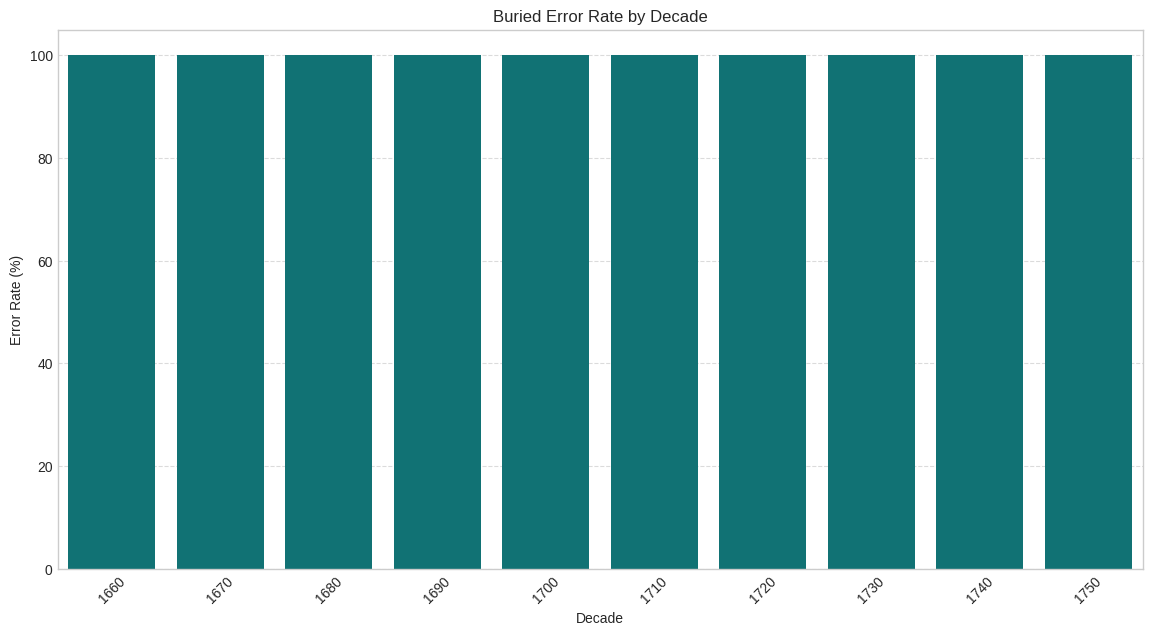

In [730]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Define our color palette
custom_palette = {'buried': '#008285'}

grouped_comparison_buried['decade'] = grouped_comparison_buried['decade'].astype(int)

sns.barplot(data=grouped_comparison_buried, x='decade', y='error_rate', hue='count_type', palette=custom_palette, legend=False)
plt.title('Buried Error Rate by Decade')
plt.xlabel('Decade')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

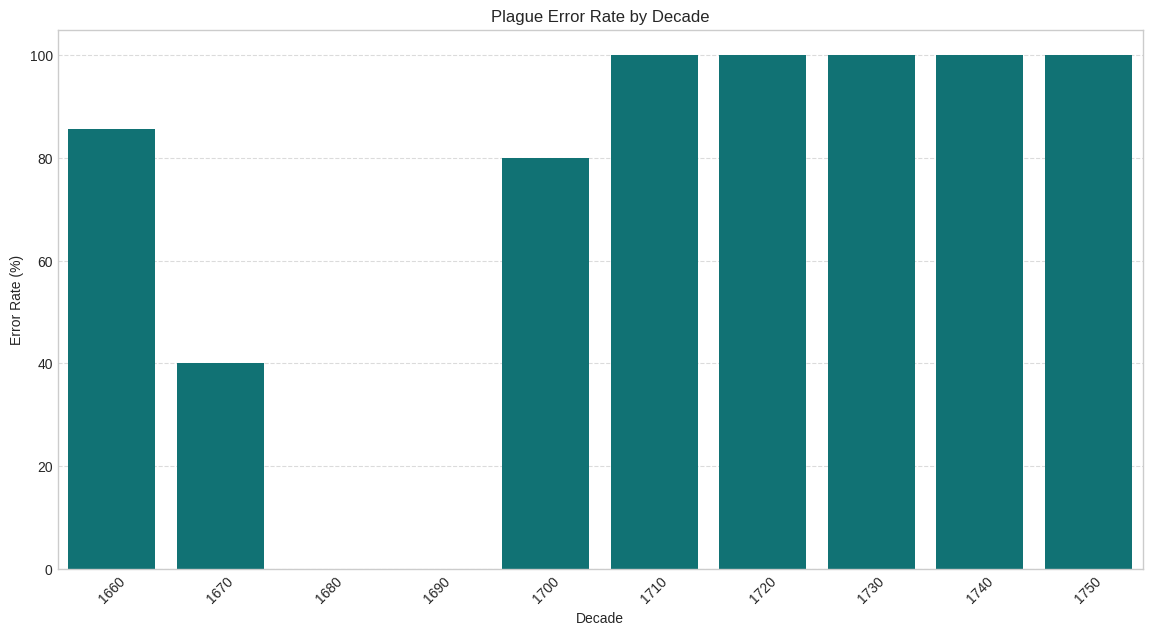

In [731]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Define our color palette
custom_palette = {'plague': '#008285'}

grouped_comparison_plague['decade'] = grouped_comparison_plague['decade'].astype(int)

sns.barplot(data=grouped_comparison_plague, x='decade', y='error_rate', hue='count_type', palette=custom_palette, legend=False)
plt.title('Plague Error Rate by Decade')
plt.xlabel('Decade')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

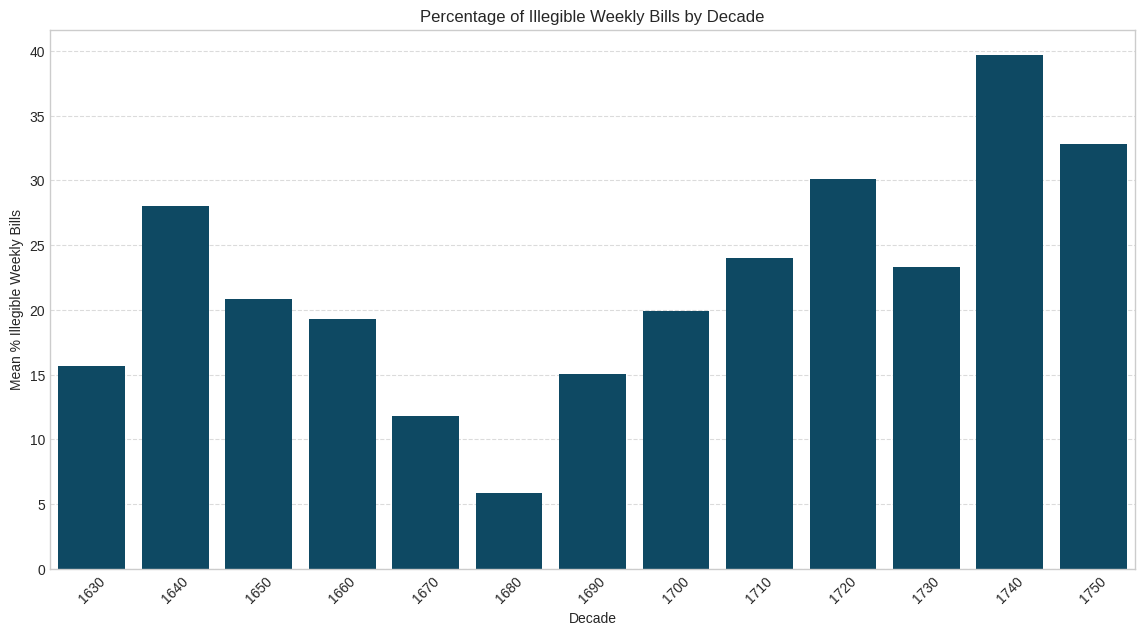

,year_range,illegible_weeks,total_unique_weeks,pct_weeks_illegible,pct_diff,start_year,decade
99,1745-1746,35,53,66.04,0.66,1745,1740
95,1741-1742,30,51,58.82,-3.26,1741,1740
96,1742-1743,29,50,58.00,-4.41,1742,1740
66,1712-1713,26,50,52.00,-4.29,1712,1710
8,1646-1647,26,49,53.06,NaN,1646,1640
...,...,...,...,...,...,...,...
20,1659-1660,2,50,4.00,NaN,1659,1650
0,1635-1636,2,20,10.00,NaN,1635,1630
21,1661-1662,2,18,11.11,NaN,1661,1660
40,1684-1685,2,53,3.77,2.02,1684,1680


In [732]:
# Bills by illegible data by decade
# Create a dataset for all weekly bills, without the year filter for illegibility calculation
all_weekly_bills = bills[bills['bill_type'] == 'weekly'].copy()

# Identify the unique weekly bills with illegible data across all years
bills_illegible_all_years = all_weekly_bills[all_weekly_bills['illegible'] == True]

# Count the illegible weeks for a given year range (all years)
illegible_counts_all_years = bills_illegible_all_years.groupby('year_range')['joinid'].nunique().reset_index()
illegible_counts_all_years.rename(columns={'joinid': 'illegible_weeks'}, inplace=True)

# Calculate the total number of unique weeks for a given year range (all years)
total_weeks_per_year_range_all_years = all_weekly_bills.groupby('year_range')['joinid'].nunique().reset_index()
total_weeks_per_year_range_all_years.rename(columns={'joinid': 'total_unique_weeks'}, inplace=True)

# Merge illegible_counts_all_years with total_weeks_per_year_range_all_years
# This temporary dataframe will hold illegibility percentage for all years
illegibility_data_all_years = illegible_counts_all_years.merge(
    total_weeks_per_year_range_all_years, on='year_range', how='left'
)
illegibility_data_all_years['pct_weeks_illegible'] = (
    illegibility_data_all_years['illegible_weeks'] / illegibility_data_all_years['total_unique_weeks'] * 100
).round(2)

# To ensure `merged_illegible_comparison` includes all years for illegibility (from 1630s),
# start the merge with `illegibility_data_all_years` and then merge `pct_diff` data.
# `subset_burials` contains `pct_diff` but only from 1663 onwards.
# Thus, `pct_diff` will be NaN for years before 1663 in the final merged DataFrame.
merged_illegible_comparison = illegibility_data_all_years.merge(
    subset_burials[['year_range', 'pct_diff']],
    on='year_range',
    how='left' # Use left merge to keep all year_range values from illegibility_data_all_years
)

# Add a 'start_year' column to merged_illegible_comparison for chronological sorting and plotting
merged_illegible_comparison['start_year'] = merged_illegible_comparison['year_range'].apply(lambda x: int(x.split('-')[0]))

# Sort merged_illegible_comparison chronologically by 'start_year'
merged_illegible_comparison = merged_illegible_comparison.sort_values('start_year', ascending=True)

# Determine the decades from the new 'start_year' column
merged_illegible_comparison['decade'] = (merged_illegible_comparison['start_year'] // 10) * 10

# Group by decade and calculate the mean percentage of illegible weeks
decade_illegibility = merged_illegible_comparison.groupby('decade')['pct_weeks_illegible'].mean().reset_index()

# Convert 'decade' to integer type for cleaner display on x-axis
decade_illegibility['decade'] = decade_illegibility['decade'].astype(int)

plt.figure(figsize=(14, 7))
sns.barplot(data=decade_illegibility, x='decade', y='pct_weeks_illegible', color=PALETTE[5])
plt.title('Percentage of Illegible Weekly Bills by Decade')
plt.xlabel('Decade')
plt.ylabel('Mean % Illegible Weekly Bills')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# sort merged_illegible_comparison by the field 'illegible_weeks'
merged_illegible_comparison = merged_illegible_comparison.sort_values('illegible_weeks', ascending=False)

# Display the head of the newly structured DataFrame to confirm the year range
merged_illegible_comparison.head(100)

## Statistics

This compares the sum of all weekly plague subtotals in a single collective (e.g. "within the walls") against the subtotal for that collective in the corresponding general bill.

In [733]:
# display count_type plague ordered by weekly_sum
display(comparison[comparison['count_type'] == 'plague'].sort_values('weekly_parish_sum', ascending=False))

#display(comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'plague'].sort_values('weekly_parish_sum', ascending=False)))

,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff,decade,matches
5,1664-1665,plague,50845.0,1665.0,68598.0,-17753.0,-25.88,1660.0,False
7,1665-1666,plague,4374.0,1666.0,1998.0,2376.0,118.92,1660.0,False
9,1666-1667,plague,121.0,1667.0,35.0,86.0,245.71,1660.0,False
1,1662-1663,plague,13.0,1663.0,9.0,4.0,44.44,1660.0,False
11,1667-1668,plague,11.0,1668.0,14.0,-3.0,-21.43,1660.0,False
...,...,...,...,...,...,...,...,...,...
169,1746-1747,plague,NaN,1747.0,0.0,NaN,NaN,1740.0,False
171,1747-1748,plague,NaN,1748.0,0.0,NaN,NaN,1740.0,False
173,1748-1749,plague,NaN,1749.0,0.0,NaN,NaN,1740.0,False
175,1749-1750,plague,NaN,1750.0,0.0,NaN,NaN,1750.0,False


In [734]:
# Stats on weekly correct vs general correct
comparison_subtotals_general_plague = comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'plague']

# remove entries from comparison_subtotals_general_plague where the field 'general_total' == 0
comparison_subtotals_general_plague = comparison_subtotals_general_plague[comparison_subtotals_general_plague['general_total'] != 0]

perfect_matches = (comparison_subtotals_general_plague['difference'] == 0).sum()
within_50 = (abs(comparison_subtotals_general_plague['difference']) <= 10).sum()
within_100 = (abs(comparison_subtotals_general_plague['difference']) <= 100).sum()
positive = (comparison_subtotals_general_plague['difference'] > 0).sum()
negative = (comparison_subtotals_general_plague['difference'] < 0).sum()

print(f"How well do the printed subtotals in the weekly bills match the reported subtotals in the general bills?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"Within ±50: {within_10:,} ({within_50/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"Within ±100: {within_100:,} ({within_100/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {comparison_subtotals_general_plague['difference'].mean():+.1f}\n"
      f"Median difference: {comparison_subtotals_general_plague['difference'].median():+.1f}\n"
      f"Std: {comparison_subtotals_general_plague['difference'].std():.1f}\n"
      f"Range: {comparison_subtotals_general_plague['difference'].min():+.1f} to {comparison_subtotals_general_plague['difference'].max():+.1f}")

How well do the printed subtotals in the weekly bills match the reported subtotals in the general bills?
Perfect matches: 11 (34.4%)
Within ±50: 37 (68.8%)
Within ±100: 24 (75.0%)

Mean difference: +519.6
Median difference: +0.0
Std: 1804.4
Range: -1084.0 to +7590.0


In [735]:
# display comparison_subtotals_general_plague
display(comparison_subtotals_general_plague)

,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
176,Middlesex and Surrey,plague,1662-1663,2,2,0,0.00
177,Middlesex and Surrey,plague,1663-1664,4,4,0,0.00
178,Middlesex and Surrey,plague,1664-1665,15696,21420,5724,26.72
179,Middlesex and Surrey,plague,1665-1666,2023,939,-1084,-115.44
180,Middlesex and Surrey,plague,1666-1667,43,11,-32,-290.91
181,Middlesex and Surrey,plague,1667-1668,6,8,2,25.00
182,Middlesex and Surrey,plague,1668-1669,5,2,-3,-150.00
184,Middlesex and Surrey,plague,1670-1671,5,5,0,0.00
185,Middlesex and Surrey,plague,1671-1672,3,3,0,0.00
186,Middlesex and Surrey,plague,1672-1673,1,1,0,0.00


This compares the sum of all weekly burial subtotals in a single collective (e.g. "within the walls") against the subtotal for that collective in the corresponding general bill.

In [736]:
display(comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'buried'])

,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
0,Middlesex and Surrey,buried,1662-1663,4177,4269,92,2.16
1,Middlesex and Surrey,buried,1663-1664,4723,4885,162,3.32
2,Middlesex and Surrey,buried,1664-1665,22156,28554,6398,22.41
3,Middlesex and Surrey,buried,1665-1666,8820,4465,-4355,-97.54
4,Middlesex and Surrey,buried,1666-1667,5685,5610,-75,-1.34
...,...,...,...,...,...,...,...
875,Without the walls,buried,1746-1747,5801,23200,17399,75.00
876,Without the walls,buried,1747-1748,5416,22228,16812,75.63
877,Without the walls,buried,1748-1749,6118,24488,18370,75.02
878,Without the walls,buried,1749-1750,5845,23304,17459,74.92


In [737]:
# fix weird error where the Laxton general_total is multiplied by 4, for reasons I don't have the time to figure out right now
# IF YOU RUN THIS CELL MORE THAN ONCE IT WILL KEEP DIVIDING BY 4 FOREVER AND YOUR DATA WILL POOF!

# for every entry in comparison_subtotals_general with 'count_type' == buried
for index, row in comparison_subtotals_general.iterrows():
    if row['count_type'] == 'buried':
      # if it's a 18th century number
      if '-16' not in row['year_range']:
        # replace general_total with general_total / 4
        comparison_subtotals_general.at[index, 'general_total'] = row['general_total'] / 4

In [738]:
# for every entry in comparison_subtotals_general with 'count_type' == buried
for index, row in comparison_subtotals_general.iterrows():
    if row['count_type'] == 'buried':
      # set difference = general_total - weekly_sum
      comparison_subtotals_general.at[index, 'difference'] = row['general_total'] - row['weekly_sum']
      # set pct_diff = difference / general_total
      comparison_subtotals_general.at[index, 'pct_diff'] = 100 * row['difference'] / row['general_total']

display(comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'buried'])

,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
0,Middlesex and Surrey,buried,1662-1663,4177,4269.0,92.0,2.155071
1,Middlesex and Surrey,buried,1663-1664,4723,4885.0,162.0,3.316274
2,Middlesex and Surrey,buried,1664-1665,22156,28554.0,6398.0,22.406668
3,Middlesex and Surrey,buried,1665-1666,8820,4465.0,-4355.0,-97.536394
4,Middlesex and Surrey,buried,1666-1667,5685,5610.0,-75.0,-1.336898
...,...,...,...,...,...,...,...
875,Without the walls,buried,1746-1747,5801,5800.0,-1.0,299.982759
876,Without the walls,buried,1747-1748,5416,5557.0,141.0,302.537340
877,Without the walls,buried,1748-1749,6118,6122.0,4.0,300.065338
878,Without the walls,buried,1749-1750,5845,5826.0,-19.0,299.673876


In [739]:
# Stats on weekly correct vs general correct
comparison_subtotals_general_plague = comparison_subtotals_general[comparison_subtotals_general['count_type'] == 'buried']

perfect_matches = (comparison_subtotals_general_plague['difference'] == 0).sum()
within_50 = (abs(comparison_subtotals_general_plague['difference']) <= 50).sum()
within_100 = (abs(comparison_subtotals_general_plague['difference']) <= 100).sum()
positive = (comparison_subtotals_general_plague['difference'] > 0).sum()
negative = (comparison_subtotals_general_plague['difference'] < 0).sum()

# calculate the absolute value of comparison_subtotals_general_plague field 'difference'
comparison_subtotals_general_plague['difference'] = abs(comparison_subtotals_general_plague['difference'])

print(f"How well do the printed subtotals in the weekly bills match the reported subtotals in the general bills?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"Within ±50: {within_50:,} ({within_50/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"Within ±100: {within_100:,} ({within_100/len(comparison_subtotals_general_plague)*100:.1f}%)\n"
      f"\n"
      f"Mean difference (abs value): {abs(comparison_subtotals_general_plague['difference']).mean():+.1f}\n"
      f"Median difference (abs value): {abs(comparison_subtotals_general_plague['difference']).median():+.1f}\n"
      f"Std: {comparison_subtotals_general_plague['difference'].std():.1f}\n"
      f"Range: {comparison_subtotals_general_plague['difference'].min():+.1f} to {comparison_subtotals_general_plague['difference'].max():+.1f}\n"
      f"\n"
      f"Mean pct_diff (abs value): {abs(comparison_subtotals_general_plague['pct_diff']).mean():+.1f}\n"
      f"Median pct_diff (abs value): {abs(comparison_subtotals_general_plague['pct_diff']).median():+.1f}\n"
      f"Std: {comparison_subtotals_general_plague['pct_diff'].std():.1f}\n"
      f"Range: {comparison_subtotals_general_plague['pct_diff'].min():+.1f} to {comparison_subtotals_general_plague['difference'].max():+.1f}\n"
      )

How well do the printed subtotals in the weekly bills match the reported subtotals in the general bills?
Perfect matches: 10 (2.8%)
Within ±50: 113 (32.1%)
Within ±100: 181 (51.4%)

Mean difference (abs value): +514.3
Median difference (abs value): +96.5
Std: 1193.3
Range: +0.0 to +7776.0

Mean pct_diff (abs value): +179.5
Median pct_diff (abs value): +298.6
Std: 153.9
Range: -121.7 to +7776.0



In [740]:
# print comparison_subtotals_general_plague sorted by 'difference'
comparison_subtotals_general_plague.head(100)

,subtotal_category,count_type,year_range,weekly_sum,general_total,difference,pct_diff
0,Middlesex and Surrey,buried,1662-1663,4177,4269.0,92.0,2.155071
1,Middlesex and Surrey,buried,1663-1664,4723,4885.0,162.0,3.316274
2,Middlesex and Surrey,buried,1664-1665,22156,28554.0,6398.0,22.406668
3,Middlesex and Surrey,buried,1665-1666,8820,4465.0,4355.0,-97.536394
4,Middlesex and Surrey,buried,1666-1667,5685,5610.0,75.0,-1.336898
...,...,...,...,...,...,...,...
271,Westminster,buried,1669-1670,3487,3608.0,121.0,3.353659
272,Westminster,buried,1670-1671,2743,2710.0,33.0,-1.217712
273,Westminster,buried,1671-1672,2990,3063.0,73.0,2.383284
274,Westminster,buried,1672-1673,3268,3184.0,84.0,-2.638191


This is the weekly parish sums vs. the printed general bill totals, for plague, with one entry for each of the 89 years under analysis.

In [745]:
display(comparison[comparison['count_type'] == 'plague'])

,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff,decade,matches
1,1662-1663,plague,13.0,1663.0,9.0,4.0,44.44,1660.0,False
3,1663-1664,plague,6.0,1664.0,6.0,0.0,0.00,1660.0,True
5,1664-1665,plague,50845.0,1665.0,68598.0,-17753.0,-25.88,1660.0,False
7,1665-1666,plague,4374.0,1666.0,1998.0,2376.0,118.92,1660.0,False
9,1666-1667,plague,121.0,1667.0,35.0,86.0,245.71,1660.0,False
...,...,...,...,...,...,...,...,...,...
169,1746-1747,plague,NaN,1747.0,0.0,NaN,NaN,1740.0,False
171,1747-1748,plague,NaN,1748.0,0.0,NaN,NaN,1740.0,False
173,1748-1749,plague,NaN,1749.0,0.0,NaN,NaN,1740.0,False
175,1749-1750,plague,NaN,1750.0,0.0,NaN,NaN,1750.0,False


In [750]:
# Stats of what percentage of the subtotals that match
comparison_plague = comparison[comparison['count_type'] == 'plague']

perfect_matches = (comparison_plague['difference'] == 0).sum()
within_5 = (abs(comparison_plague['difference']) <= 50).sum()
within_10 = (abs(comparison_plague['difference']) <= 100).sum()
positive = (comparison_plague['difference'] > 0).sum()
negative = (comparison_plague['difference'] < 0).sum()

print(f"Does our sum of the count of each parish by week equal the reported general bill?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_plague)*100:.1f}%)\n"
      f"Within ±5: {within_5:,} ({within_5/len(comparison_plague)*100:.1f}%)\n"
      f"Within ±10: {within_10:,} ({within_10/len(comparison_plague)*100:.1f}%)\n"
      f"\n"
      f"Mean difference (abs value): {abs(comparison_plague['difference']).mean():+.1f}\n"
      f"Median difference (abs value): {abs(comparison_plague['difference']).median():+.1f}\n"
      f"Std: {comparison_plague['difference'].std():.1f}\n"
      f"Range: {comparison_plague['difference'].min():+.1f} to {comparison_plague['difference'].max():+.1f}")

Does our sum of the count of each parish by week equal the reported general bill?
Perfect matches: 29 (32.6%)
Within ±5: 36 (40.4%)
Within ±10: 37 (41.6%)

Mean difference (abs value): +518.8
Median difference (abs value): +0.0
Std: 2878.4
Range: -17753.0 to +2376.0


This is the weekly parish sums vs. the printed general bill totals, for burials, with one entry for each of the 89 years under analysis.

In [754]:
# Stats of what percentage of the subtotals that match
comparison_buried = comparison[comparison['count_type'] == 'buried']

perfect_matches = (comparison_buried['difference'] == 0).sum()
within_50 = (abs(comparison_buried['difference']) <= 50).sum()
within_100 = (abs(comparison_buried['difference']) <= 100).sum()
positive = (comparison_buried['difference'] > 0).sum()
negative = (comparison_buried['difference'] < 0).sum()

print(f"Does our sum of the count of each parish by week equal the reported general bill?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_buried)*100:.1f}%)\n"
      f"Within ±50: {within_50:,} ({within_50/len(comparison_buried)*100:.1f}%)\n"
      f"Within ±100: {within_100:,} ({within_100/len(comparison_buried)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {abs(comparison_buried['difference']).mean():+.1f}\n"
      f"Median difference: {abs(comparison_buried['difference']).median():+.1f}\n"
      f"Std: {comparison_buried['difference'].std():.1f}\n"
      f"Range: {comparison_buried['difference'].min():+.1f} to {comparison_buried['difference'].max():+.1f}\n"
      f"\n"
      f"Mean pct_diff (abs value): {abs(comparison_buried['pct_diff']).mean():+.1f}\n"
      f"Median pct_diff (abs value): {abs(comparison_buried['pct_diff']).median():+.1f}\n"
      f"Std: {comparison_buried['pct_diff'].std():.1f}\n"
      f"Range: {comparison_buried['pct_diff'].min():+.1f} to {comparison_buried['difference'].max():+.1f}\n"
      )

Does our sum of the count of each parish by week equal the reported general bill?
Perfect matches: 0 (0.0%)
Within ±50: 11 (12.4%)
Within ±100: 23 (25.8%)

Mean difference: +1221.7
Median difference: +442.0
Std: 3392.7
Range: -21625.0 to +1000.0

Mean pct_diff (abs value): +4.3
Median pct_diff (abs value): +1.8
Std: 9.9
Range: -60.7 to +1000.0



In [755]:
# print comparison_buried sorted by pct_diff
comparison_buried = comparison_buried.sort_values('pct_diff', ascending=False)
comparison_buried.head(100)

,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff,decade,matches
6,1665-1666,buried,13502.0,1666.0,12738.0,764.0,6.00,1660.0,False
66,1695-1696,buried,19008.0,1696.0,18008.0,1000.0,5.55,1690.0,False
24,1674-1675,buried,17720.0,1675.0,17244.0,476.0,2.76,1670.0,False
56,1690-1691,buried,23260.0,1691.0,22691.0,569.0,2.51,1690.0,False
142,1733-1734,buried,26703.0,1734.0,26062.0,641.0,2.46,1730.0,False
...,...,...,...,...,...,...,...,...,...
76,1700-1701,buried,14996.0,1701.0,20471.0,-5475.0,-26.75,1700.0,False
0,1662-1663,buried,10780.0,1663.0,15356.0,-4576.0,-29.80,1660.0,False
112,1718-1719,buried,19115.0,1719.0,28347.0,-9232.0,-32.57,1710.0,False
156,1740-1741,buried,17834.0,1741.0,32169.0,-14335.0,-44.56,1740.0,False


In [762]:
# divide into 17th and 18th century datasets to examine the impact of Laxton illegibility
comparison_buried_17th = comparison_buried[comparison_buried['year'] <= 1700]
comparison_buried_18th = comparison_buried[comparison_buried['year'] > 1700]

# print comparison_buried_17th sorted by year
comparison_buried_17th = comparison_buried_17th.sort_values('year', ascending=True)
display(comparison_buried_17th)

,year_range,count_type,weekly_parish_sum,year,general_total,difference,pct_diff,decade,matches
0,1662-1663,buried,10780.0,1663.0,15356.0,-4576.0,-29.80,1660.0,False
2,1663-1664,buried,17829.0,1664.0,18297.0,-468.0,-2.56,1660.0,False
4,1664-1665,buried,75681.0,1665.0,97306.0,-21625.0,-22.22,1660.0,False
6,1665-1666,buried,13502.0,1666.0,12738.0,764.0,6.00,1660.0,False
8,1666-1667,buried,15780.0,1667.0,15842.0,-62.0,-0.39,1660.0,False
10,1667-1668,buried,15383.0,1668.0,17278.0,-1895.0,-10.97,1660.0,False
12,1668-1669,buried,19343.0,1669.0,19266.0,77.0,0.40,1660.0,False
14,1669-1670,buried,20478.0,1670.0,20198.0,280.0,1.39,1670.0,False
16,1670-1671,buried,15891.0,1671.0,15729.0,162.0,1.03,1670.0,False
18,1671-1672,buried,17787.0,1672.0,18230.0,-443.0,-2.43,1670.0,False


In [757]:
# Stats of what percentage of the subtotals that match for 17th century
perfect_matches = (comparison_buried_17th['difference'] == 0).sum()
within_50 = (abs(comparison_buried_17th['difference']) <= 50).sum()
within_100 = (abs(comparison_buried_17th['difference']) <= 100).sum()
positive = (comparison_buried_17th['difference'] > 0).sum()
negative = (comparison_buried_17th['difference'] < 0).sum()

print(f"Does our sum of the count of each parish by week equal the reported general bill?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_buried_17th)*100:.1f}%)\n"
      f"Within ±50: {within_50:,} ({within_50/len(comparison_buried_17th)*100:.1f}%)\n"
      f"Within ±100: {within_100:,} ({within_100/len(comparison_buried_17th)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {abs(comparison_buried_17th['difference']).mean():+.1f}\n"
      f"Median difference: {abs(comparison_buried_17th['difference']).median():+.1f}\n"
      f"Std: {comparison_buried_17th['difference'].std():.1f}\n"
      f"Range: {comparison_buried_17th['difference'].min():+.1f} to {comparison_buried_17th['difference'].max():+.1f}\n"
      f"\n"
      f"Mean pct_diff (abs value): {abs(comparison_buried_17th['pct_diff']).mean():+.1f}\n"
      f"Median pct_diff (abs value): {abs(comparison_buried_17th['pct_diff']).median():+.1f}\n"
      f"Std: {comparison_buried_17th['pct_diff'].std():.1f}\n"
      f"Range: {comparison_buried_17th['pct_diff'].min():+.1f} to {comparison_buried_17th['difference'].max():+.1f}\n"
      )

Does our sum of the count of each parish by week equal the reported general bill?
Perfect matches: 0 (0.0%)
Within ±50: 5 (13.2%)
Within ±100: 9 (23.7%)

Mean difference: +1153.5
Median difference: +444.5
Std: 3587.5
Range: -21625.0 to +1000.0

Mean pct_diff (abs value): +3.7
Median pct_diff (abs value): +2.1
Std: 6.7
Range: -29.8 to +1000.0



In [758]:
# Stats of what percentage of the subtotals that match for 18th century
perfect_matches = (comparison_buried_18th['difference'] == 0).sum()
within_50 = (abs(comparison_buried_18th['difference']) <= 50).sum()
within_100 = (abs(comparison_buried_18th['difference']) <= 100).sum()
positive = (comparison_buried_18th['difference'] > 0).sum()
negative = (comparison_buried_18th['difference'] < 0).sum()

print(f"Does our sum of the count of each parish by week equal the reported general bill?\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_buried_18th)*100:.1f}%)\n"
      f"Within ±50: {within_50:,} ({within_50/len(comparison_buried_18th)*100:.1f}%)\n"
      f"Within ±100: {within_100:,} ({within_100/len(comparison_buried_18th)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {abs(comparison_buried_18th['difference']).mean():+.1f}\n"
      f"Median difference: {abs(comparison_buried_18th['difference']).median():+.1f}\n"
      f"Std: {comparison_buried_18th['difference'].std():.1f}\n"
      f"Range: {comparison_buried_18th['difference'].min():+.1f} to {comparison_buried_18th['difference'].max():+.1f}\n"
      f"\n"
      f"Mean pct_diff (abs value): {abs(comparison_buried_18th['pct_diff']).mean():+.1f}\n"
      f"Median pct_diff (abs value): {abs(comparison_buried_18th['pct_diff']).median():+.1f}\n"
      f"Std: {comparison_buried_18th['pct_diff'].std():.1f}\n"
      f"Range: {comparison_buried_18th['pct_diff'].min():+.1f} to {comparison_buried_18th['difference'].max():+.1f}\n"
      )

Does our sum of the count of each parish by week equal the reported general bill?
Perfect matches: 0 (0.0%)
Within ±50: 6 (11.8%)
Within ±100: 14 (27.5%)

Mean difference: +1272.4
Median difference: +388.0
Std: 3273.3
Range: -16103.0 to +641.0

Mean pct_diff (abs value): +4.8
Median pct_diff (abs value): +1.5
Std: 11.8
Range: -60.7 to +641.0

